In [4]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [5]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']


    # Get vertex positions
    vertex_pos = B_vertex['vertex.pos_'].array()
    df['vertex_pos_x'] = np.array(vertex_pos['fX'])
    df['vertex_pos_y'] = np.array(vertex_pos['fY'])
    df['vertex_pos_z'] = np.array(vertex_pos['fZ'])

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])
    # Get number of hits in Ecal clusters

    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get number of hits on track
    df['ele_trk_nhits'] = np.array(B_ele[ 'ele.track_/ele.track_.n_hits_'])
    df['pos_trk_nhits'] = np.array(B_pos[ 'pos.track_/pos.track_.n_hits_'])
    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])
    # Collect track parameters for electrons and positrons
    df['ele_phi0'] = -np.array(B_ele['ele.track_/ele.track_.phi0_'])
    df['ele_dp'] = np.array(B_ele['ele.track_/ele.track_.d0_'])
    df['ele_kappa_o_alpha'] = -np.array(B_ele['ele.track_/ele.track_.omega_'])
    df['ele_dz'] = -np.array(B_ele['ele.track_/ele.track_.z0_'])
    df['ele_tan_lambda'] = -np.array(B_ele['ele.track_/ele.track_.tan_lambda_'])
    df['pos_phi0'] = -np.array(B_pos['pos.track_/pos.track_.phi0_'])
    df['pos_dp'] = np.array(B_pos['pos.track_/pos.track_.d0_'])
    df['pos_kappa_o_alpha'] = -np.array(B_pos['pos.track_/pos.track_.omega_'])
    df['pos_dz'] = -np.array(B_pos['pos.track_/pos.track_.z0_'])
    df['pos_tan_lambda'] = -np.array(B_pos['pos.track_/pos.track_.tan_lambda_'])

    df['e_Pz'] = np.array(B_ele['ele.pz_'])
    df['e_Px'] = np.array(B_ele['ele.px_'])
    df['e_Py'] = np.array(B_ele['ele.py_'])
    df['p_Pz'] = np.array(B_pos['pos.pz_'])
    df['p_Px'] = np.array(B_pos['pos.px_'])
    df['p_Py'] = np.array(B_pos['pos.py_'])

    df['ele_P'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    df['pos_P'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)

    df['e_P'] = np.sqrt(df['e_Px']**2 + df['e_Py']**2 + df['e_Pz']**2)
    df['p_P'] = np.sqrt(df['p_Px']**2 + df['p_Py']**2 + df['p_Pz']**2)

    df['vertex_Ptot'] = df['ele_P'] + df['pos_P']
    df['Ptot'] = df['e_P'] + df['p_P']
    df['Psum'] = np.array(tree['psum'])

    return df


In [27]:
# Create dataframes 
df_tritrig= make_df('/Users/mghrear/data/HPS_mc/2019_tritrig_pulser_recon_2_pt2/tritrig.root')
df_data_2019 = make_df('/Users/mghrear/data/HPS_data/2019_flattened2/2019_run010051.root')
df_data_2021_v8 = make_df('/Users/mghrear/data/HPS_data/2021_flattened8292025/2021_v8.root')
df_data_2021_old = make_df('/Users/mghrear/data/HPS_data/WithChargesData/merged.root')



# 2019 Data

Text(0.5, 0, 'Psum (GeV)')

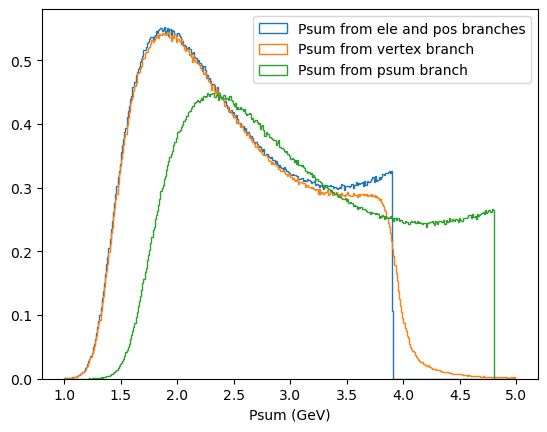

In [50]:
plt.hist(df_data_2019['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_data_2019['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_data_2019['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
#plt.hist(df_data_2019['Psum']*0.81374, bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')

plt.legend()
plt.xlabel('Psum (GeV)')


In [48]:
df_data_2019['Ptot']/df_data_2019['Psum']

0          0.813174
1          0.813174
2          0.813174
3          0.813174
4          0.813174
             ...   
6439166    0.813174
6439167    0.813174
6439168    0.813174
6439169    0.813174
6439170    0.813174
Length: 6439171, dtype: float64

# 2019 MC

Text(0.5, 0, 'Psum (GeV)')

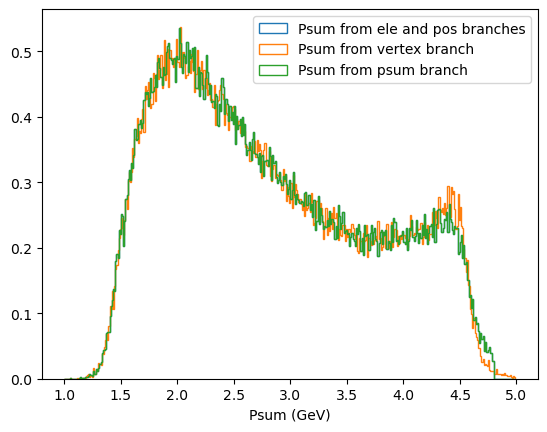

In [29]:
plt.hist(df_tritrig['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_tritrig['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_tritrig['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')

In [30]:
df_tritrig['Ptot']


0         2.050643
1         2.614587
2         1.971529
3         4.216108
4         1.727346
            ...   
126820    4.157466
126821    2.742624
126822    3.267757
126823    2.144669
126824    1.985904
Name: Ptot, Length: 126825, dtype: float64

In [31]:
df_tritrig['Psum']

0         2.050643
1         2.614587
2         1.971529
3         4.216108
4         1.727346
            ...   
126820    4.157466
126821    2.742624
126822    3.267758
126823    2.144669
126824    1.985904
Name: Psum, Length: 126825, dtype: float64

# 2021 Data

Text(0.5, 0, 'Psum (GeV)')

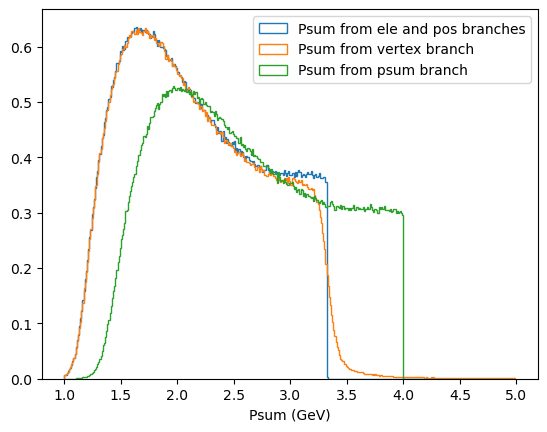

In [34]:
plt.hist(df_data_2021_v8['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_data_2021_v8['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_data_2021_v8['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')


Text(0.5, 0, 'Psum (GeV)')

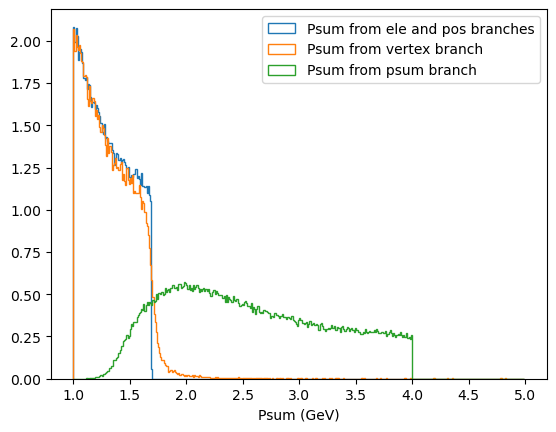

In [52]:
plt.hist(df_data_2021_old['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_data_2021_old['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_data_2021_old['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')


In [53]:
df_data_2021_old['Ptot']/df_data_2021_old['Psum']

0         0.422631
1         0.422631
2         0.422631
3         0.422631
4         0.422631
            ...   
217325    0.422631
217326    0.422631
217327    0.422631
217328    0.422631
217329    0.422631
Length: 217330, dtype: float64